# Customer Loan Approval Prediction

## Abstract
This project evaluates multiple Machine Learning Classification models to predict whether a customer will be approved for a loan. We perform complete data preprocessing, Exploratory Data Analysis (EDA), Hyperparameter tuning, and detailed model evaluation using metrics like Accuracy, Precision, Recall, F1 Score, and ROC-AUC. A final professional report is also generated.

Models Evaluated:
- Logistic Regression
- Support Vector Machine (SVM)
- Random Forest Classifier
- Gradient Boosting Classifier

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
from imblearn.over_sampling import SMOTE
import joblib
warnings.filterwarnings('ignore')

# Setup output directories
os.makedirs('outputs/models', exist_ok=True)
os.makedirs('outputs/plots', exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')


## 1. Dataset Overview and Loading

In [2]:
df = pd.read_csv('loan_prediction_dataset.csv')
print('--- Dataset Shape ---')
print(df.shape)
print('\n--- Dataset Information ---')
print(df.info())
print('\n--- Null Values ---')
print(df.isnull().sum())
print('\n--- First 5 Rows ---')
display(df.head())


--- Dataset Shape ---
(2000, 7)

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                2000 non-null   int64 
 1   Income             2000 non-null   int64 
 2   Credit_Score       2000 non-null   int64 
 3   Loan_Amount        2000 non-null   int64 
 4   Loan_Term          2000 non-null   int64 
 5   Employment_Status  2000 non-null   object
 6   Loan_Approved      2000 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 109.5+ KB
None

--- Null Values ---
Age                  0
Income               0
Credit_Score         0
Loan_Amount          0
Loan_Term            0
Employment_Status    0
Loan_Approved        0
dtype: int64

--- First 5 Rows ---


,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved
0,56,81788,334,15022,48,Employed,0
1,69,102879,781,21013,24,Self-Employed,1
2,46,58827,779,39687,60,Self-Employed,0
3,32,127188,364,16886,24,Unemployed,0
4,60,25655,307,26256,36,Unemployed,0


## 2. Exploratory Data Analysis (EDA)

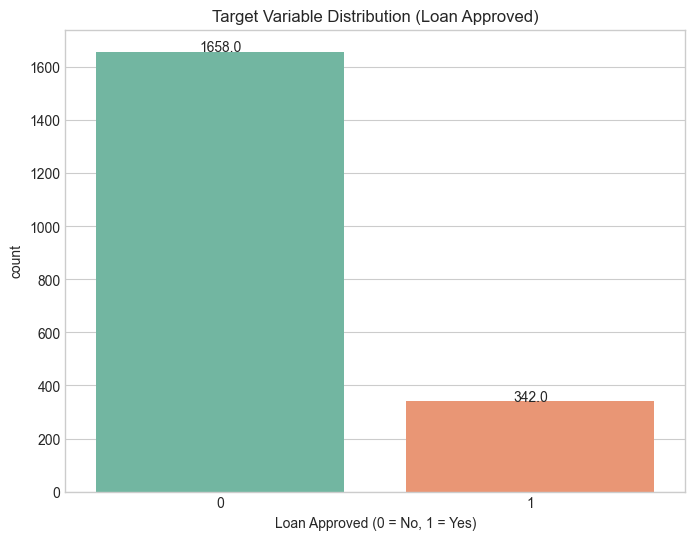

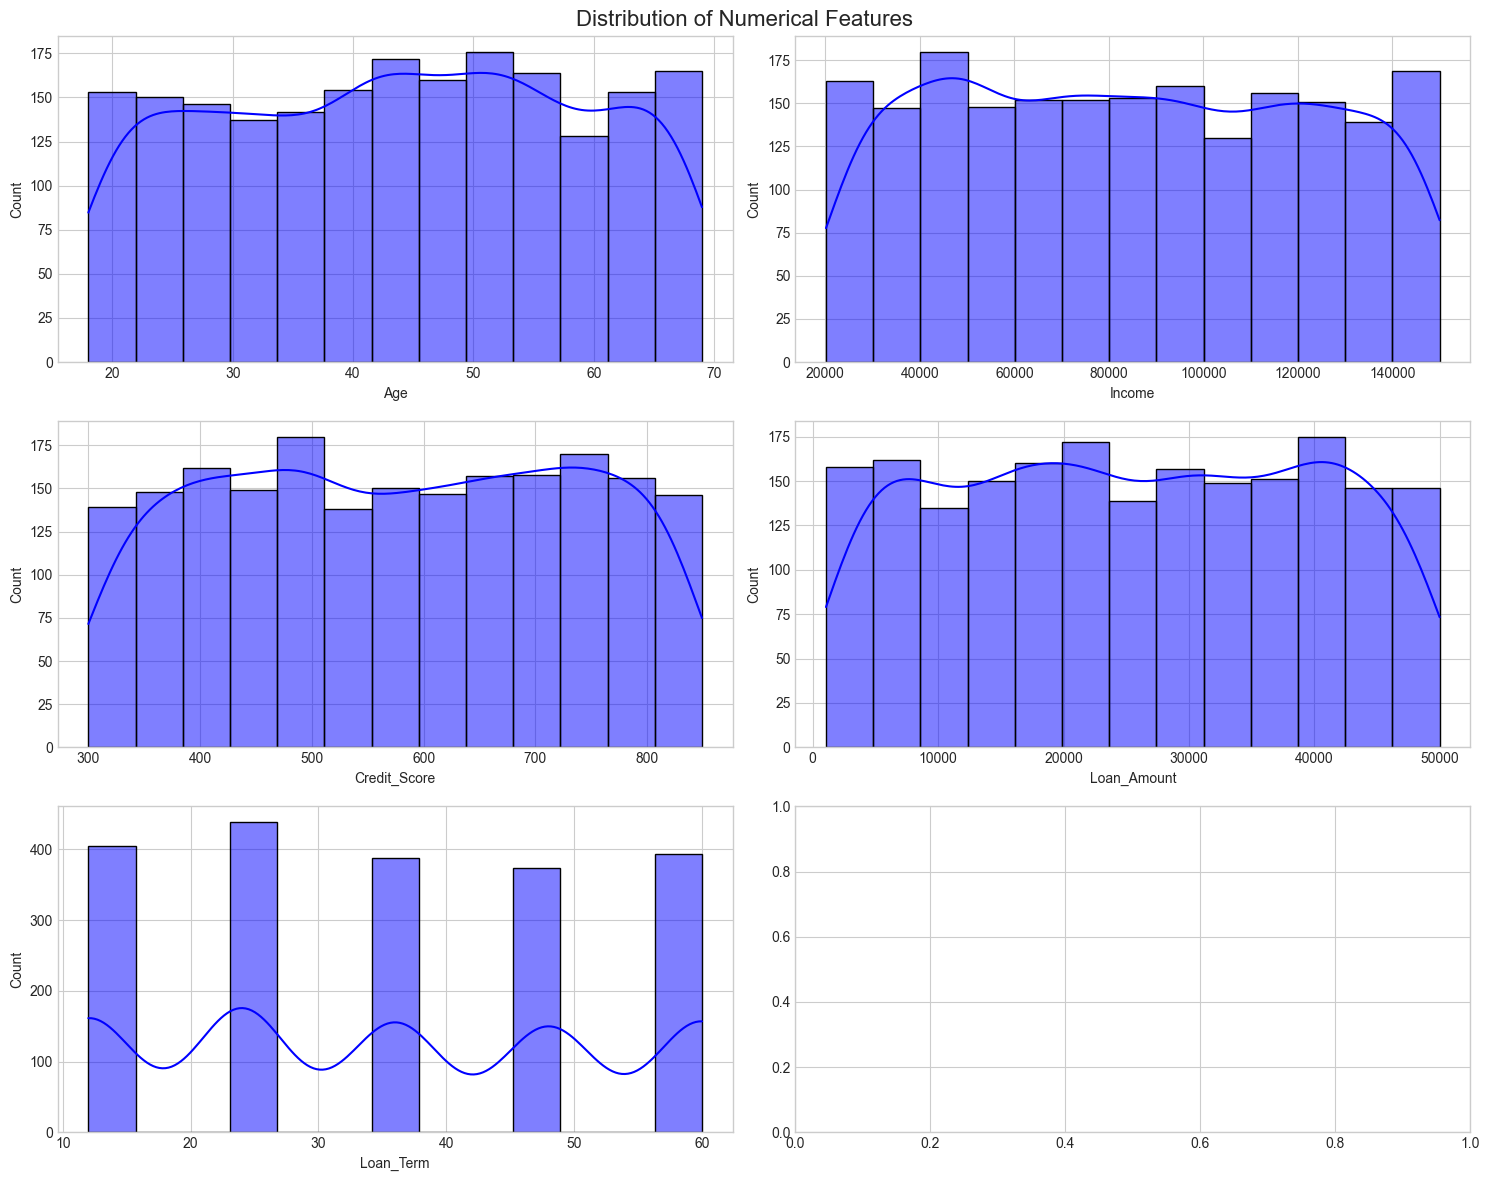

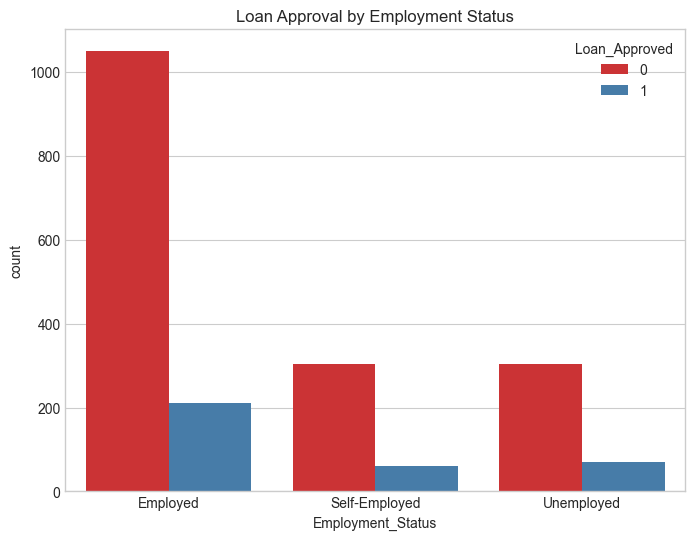

In [3]:
# 1. Class Imbalance (Target Variable Distribution)
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='Loan_Approved', palette='Set2')
plt.title('Target Variable Distribution (Loan Approved)')
plt.xlabel('Loan Approved (0 = No, 1 = Yes)')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')
plt.savefig('outputs/plots/target_distribution.png', bbox_inches='tight')
plt.show()

# 2. Distribution Plots for Numerical Features
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('Loan_Approved')
fig, axes = plt.subplots(len(num_cols)//2 + len(num_cols)%2, 2, figsize=(15, 12))
fig.suptitle('Distribution of Numerical Features', fontsize=16)
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i//2, i%2], color='blue')
plt.tight_layout()
plt.savefig('outputs/plots/numerical_distributions.png', bbox_inches='tight')
plt.show()

# 3. Count Plot for Categorical Features
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Employment_Status', hue='Loan_Approved', palette='Set1')
plt.title('Loan Approval by Employment Status')
plt.savefig('outputs/plots/employment_status_count.png', bbox_inches='tight')
plt.show()


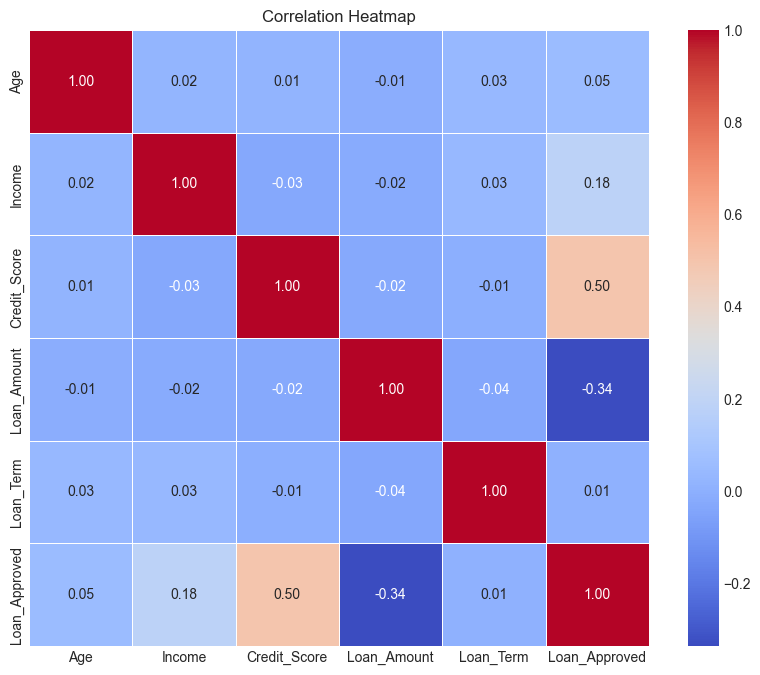

In [4]:
# 4. Correlation Heatmap (only numerical for now)
plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.savefig('outputs/plots/correlation_heatmap.png', bbox_inches='tight')
plt.show()


## 3. Data Preprocessing & Feature Engineering

In [5]:
# Handle duplicates
df.drop_duplicates(inplace=True)

# Handle missing values (if any)
df.fillna(df.median(numeric_only=True), inplace=True)
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Encode categorical variables
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Split Features and Target
X = df.drop('Loan_Approved', axis=1)
y = df['Loan_Approved']

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE for Class Imbalance on Training Data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'Original Training Target Distribution:\n{y_train.value_counts()}')
print(f'SMOTE Training Target Distribution:\n{pd.Series(y_train_sm).value_counts()}')


Original Training Target Distribution:
Loan_Approved
0    1326
1     274
Name: count, dtype: int64
SMOTE Training Target Distribution:
Loan_Approved
0    1326
1    1326
Name: count, dtype: int64


## 4. Model Training and Hyperparameter Tuning

In [6]:
# Define models and hyperparameters grids
models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=42), {
        'C': [0.1, 1.0, 10.0]
    }),
    'SVM': (SVC(probability=True, random_state=42), {
        'C': [0.1, 1, 10],
        'kernel': ['rbf']
    }),
    'Random Forest': (RandomForestClassifier(random_state=42), {
        'n_estimators': [50, 100],
        'max_depth': [None, 10, 20]
    }),
    'Gradient Boosting': (GradientBoostingClassifier(random_state=42), {
        'n_estimators': [50, 100],
        'learning_rate': [0.01, 0.1]
    })
}

best_models = {}
model_results = []

for name, (model, params) in models.items():
    print(f'Training {name} with GridSearchCV...')
    grid = GridSearchCV(model, params, cv=3, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train_sm, y_train_sm)
    best_models[name] = grid.best_estimator_
    
    # Predict on test set
    y_pred = grid.predict(X_test)
    y_pred_proba = grid.predict_proba(X_test)[:, 1] if hasattr(grid.best_estimator_, 'predict_proba') else [0]*len(y_test)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    model_results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'AUC': roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    })
    print(f'{name} trained! Best Params: {grid.best_params_}\n')


Training Logistic Regression with GridSearchCV...


Logistic Regression trained! Best Params: {'C': 0.1}

Training SVM with GridSearchCV...


SVM trained! Best Params: {'C': 10, 'kernel': 'rbf'}

Training Random Forest with GridSearchCV...


Random Forest trained! Best Params: {'max_depth': 10, 'n_estimators': 100}

Training Gradient Boosting with GridSearchCV...


Gradient Boosting trained! Best Params: {'learning_rate': 0.1, 'n_estimators': 50}



## 5. Model Evaluation and Comparison

In [7]:
results_df = pd.DataFrame(model_results).drop(['y_pred', 'y_pred_proba'], axis=1)
results_df['Rank'] = results_df['Accuracy'].rank(ascending=False).astype(int)
results_df = results_df.sort_values('Rank').set_index('Rank')
print('--- Final Model Ranking Table ---')
display(results_df)

# Save the trained models
for name, model in best_models.items():
    model_filename = f'outputs/models/{name.replace(" ", "_").lower()}.pkl'
    joblib.dump(model, model_filename)
    print(f'Saved {name} to {model_filename}')


--- Final Model Ranking Table ---


,Model,Accuracy,Precision,Recall,F1 Score,AUC
Rank,,,,,,
1,Random Forest,1.000,1.000000,1.000000,1.000000,1.000000
1,Gradient Boosting,1.000,1.000000,1.000000,1.000000,1.000000
3,SVM,0.975,0.939394,0.911765,0.925373,0.995969
4,Logistic Regression,0.880,0.590909,0.955882,0.730337,0.965583


Saved Logistic Regression to outputs/models/logistic_regression.pkl
Saved SVM to outputs/models/svm.pkl
Saved Random Forest to outputs/models/random_forest.pkl
Saved Gradient Boosting to outputs/models/gradient_boosting.pkl


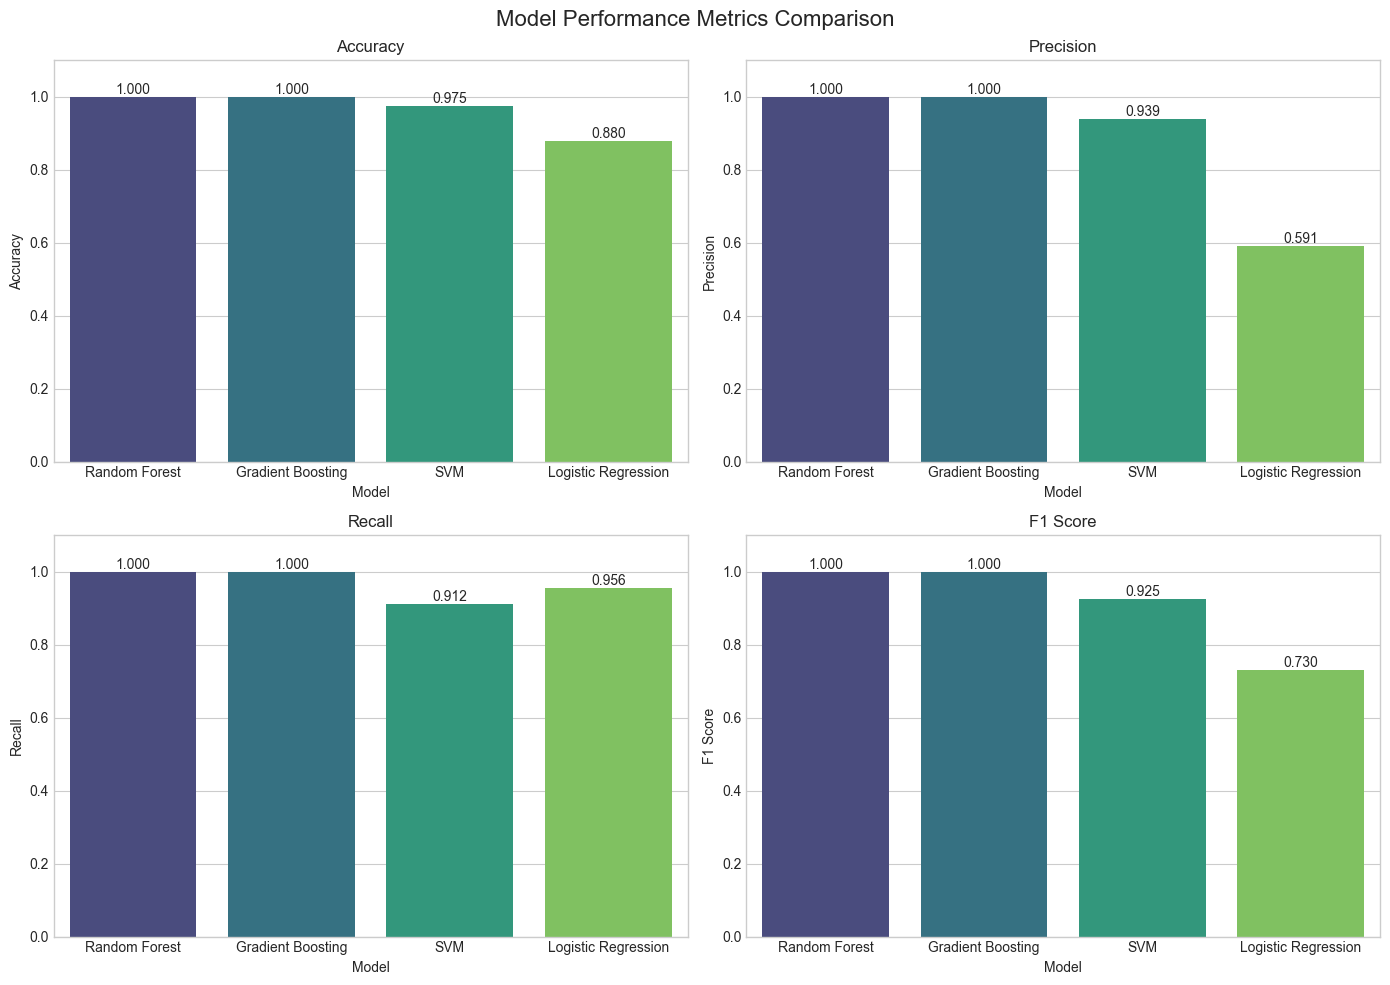

In [8]:
# Metric Comparison Bar Charts
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance Metrics Comparison', fontsize=16)
for i, metric in enumerate(metrics):
    ax = axes[i//2, i%2]
    sns.barplot(data=results_df, x='Model', y=metric, ax=ax, palette='viridis')
    ax.set_title(metric)
    ax.set_ylim(0, 1.1)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')
plt.tight_layout()
plt.savefig('outputs/plots/metrics_comparison.png', bbox_inches='tight')
plt.show()


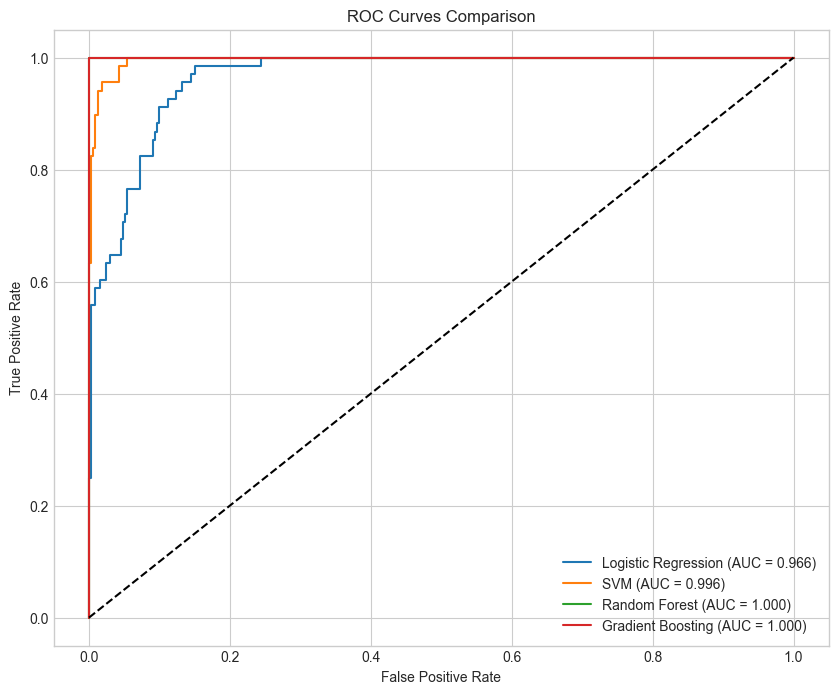

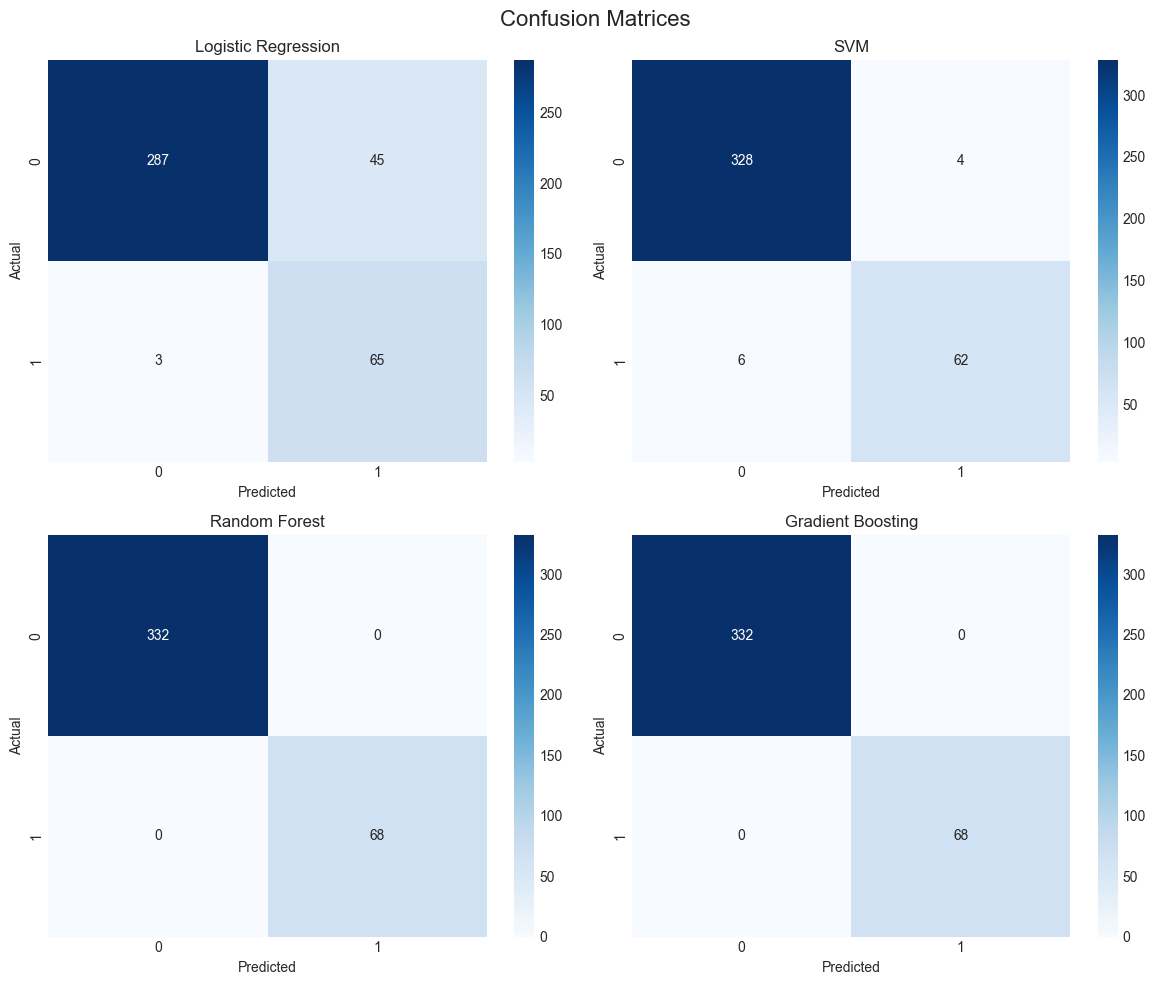

In [9]:
# ROC Curves Comparison
plt.figure(figsize=(10, 8))
for res in model_results:
    fpr, tpr, _ = roc_curve(y_test, res['y_pred_proba'])
    plt.plot(fpr, tpr, label=f"{res['Model']} (AUC = {res['AUC']:.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curves Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.savefig('outputs/plots/roc_curves.png', bbox_inches='tight')
plt.show()

# Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Confusion Matrices', fontsize=16)
for i, res in enumerate(model_results):
    cm = confusion_matrix(y_test, res['y_pred'])
    ax = axes[i//2, i%2]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(res['Model'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('outputs/plots/confusion_matrices.png', bbox_inches='tight')
plt.show()


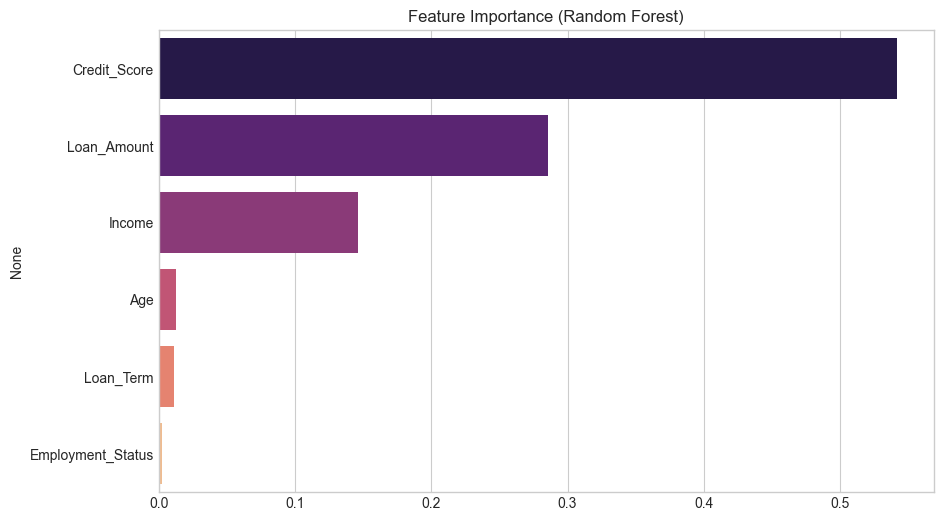

In [10]:
# Feature Importance for Random Forest
rf_model = best_models['Random Forest']
importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='magma')
plt.title('Feature Importance (Random Forest)')
plt.savefig('outputs/plots/feature_importance.png', bbox_inches='tight')
plt.show()
